# HMM-Conditional Synthetic Rainfall: v5 & v6 Evaluation

Compares the two newly generated datasets against 10-year real Astlingen data:
- **v5** — 105,120-interval direct HMM conditioning (Run ID: `3559f298`)
- **v6** — 365-day climatological HMM conditioning (Run ID: `045d9e20`)

Evaluation dimensions:
1. Basic Statistics
2. Intensity Distribution (full + wet-only)
3. Wet/Dry Spell Analysis
4. Temporal Autocorrelation
5. Extreme Value Analysis
6. Hourly & Daily Aggregation
7. Storm Event Characteristics
8. Head-to-Head v5 vs v6 Comparison
9. RL-Fitness Scorecard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')
import os

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

COLORS = {'Real': '#2b7bb9', 'v5 (105k HMM)': '#e85d26', 'v6 (365 HMM)': '#2ca02c'}

BASE = os.path.abspath('..')   # project root (if notebook is in data_analysis/)
# If running from project root, change to:
# BASE = os.path.abspath('.')

print('Project root:', BASE)

Project root: /Users/tanyawarrier/Desktop/projects/ImagenFew


## 1. Load Datasets

In [2]:
# ── Load Real Data (4-gauge average, 5-min resolution) ─────────────────────
real_path = os.path.join(BASE, 'data', 'rainfall', 'train_dataset.csv')
df_real_raw = pd.read_csv(real_path, parse_dates=['datetime'])
df_real = df_real_raw[['datetime', 'avg_rainfall']].copy()
df_real.columns = ['date', 'avg_rainfall']

# ── Load v5 (105k HMM) ─────────────────────────────────────────────────────
v5_path = os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v5.csv')
df_v5 = pd.read_csv(v5_path, parse_dates=['date'])
df_v5['avg_rainfall'] = df_v5['avg_rainfall'].clip(lower=0)
df_v5.loc[df_v5['avg_rainfall'] < 0.005, 'avg_rainfall'] = 0.0

# ── Load v6 (365 HMM) ──────────────────────────────────────────────────────
v6_path = os.path.join(BASE, 'results', 'generated_data', 'rainfall_synthetic_10y_v6.csv')
df_v6 = pd.read_csv(v6_path, parse_dates=['date'])
df_v6['avg_rainfall'] = df_v6['avg_rainfall'].clip(lower=0)
df_v6.loc[df_v6['avg_rainfall'] < 0.005, 'avg_rainfall'] = 0.0

real  = df_real['avg_rainfall'].values
v5    = df_v5['avg_rainfall'].values
v6    = df_v6['avg_rainfall'].values

print(f'Real  : {len(real):,} timesteps   {df_real["date"].iloc[0]} → {df_real["date"].iloc[-1]}')
print(f'v5    : {len(v5):,} timesteps   {df_v5["date"].iloc[0]} → {df_v5["date"].iloc[-1]}')
print(f'v6    : {len(v6):,} timesteps   {df_v6["date"].iloc[0]} → {df_v6["date"].iloc[-1]}')

Real  : 838,656 timesteps   2000-01-01 00:00:00 → 2009-12-21 23:55:00
v5    : 1,051,200 timesteps   2026-01-01 00:00:00 → 2035-12-29 23:55:00
v6    : 1,051,200 timesteps   2026-01-01 00:00:00 → 2035-12-29 23:55:00


## 2. Basic Statistics

In [3]:
def summary(arr, label):
    nz = arr[arr > 0]
    return {
        'Dataset'         : label,
        'N'               : len(arr),
        'Mean'            : arr.mean(),
        'Std'             : arr.std(),
        'Max'             : arr.max(),
        'P90'             : np.percentile(arr, 90),
        'P99'             : np.percentile(arr, 99),
        'P99.9'           : np.percentile(arr, 99.9),
        'Zero %'          : (arr == 0).mean() * 100,
        'Mean (wet)'      : nz.mean() if len(nz) else 0,
        'Std (wet)'       : nz.std() if len(nz) else 0,
        'Skewness'        : stats.skew(arr),
        'Kurtosis'        : stats.kurtosis(arr),
    }

df_stats = pd.DataFrame([summary(real, 'Real'), summary(v5, 'v5 (105k HMM)'), summary(v6, 'v6 (365 HMM)')])
df_stats = df_stats.set_index('Dataset').T
pd.set_option('display.float_format', '{:.5f}'.format)
df_stats

Dataset,Real,v5 (105k HMM),v6 (365 HMM)
N,838656.00000,1051200.00000,1051200.00000
Mean,0.00684,0.00678,0.00667
Std,0.04694,0.04361,0.04371
Max,5.55500,3.90054,3.79208
P90,0.00000,0.00000,0.00000
P99,0.16000,0.15897,0.16174
P99.9,0.56500,0.56737,0.56637
Zero %,90.91391,90.49258,91.11682
Mean (wet),0.07531,0.07127,0.07511
Std (wet),0.13818,0.12412,0.12792


## 3. Intensity Distribution

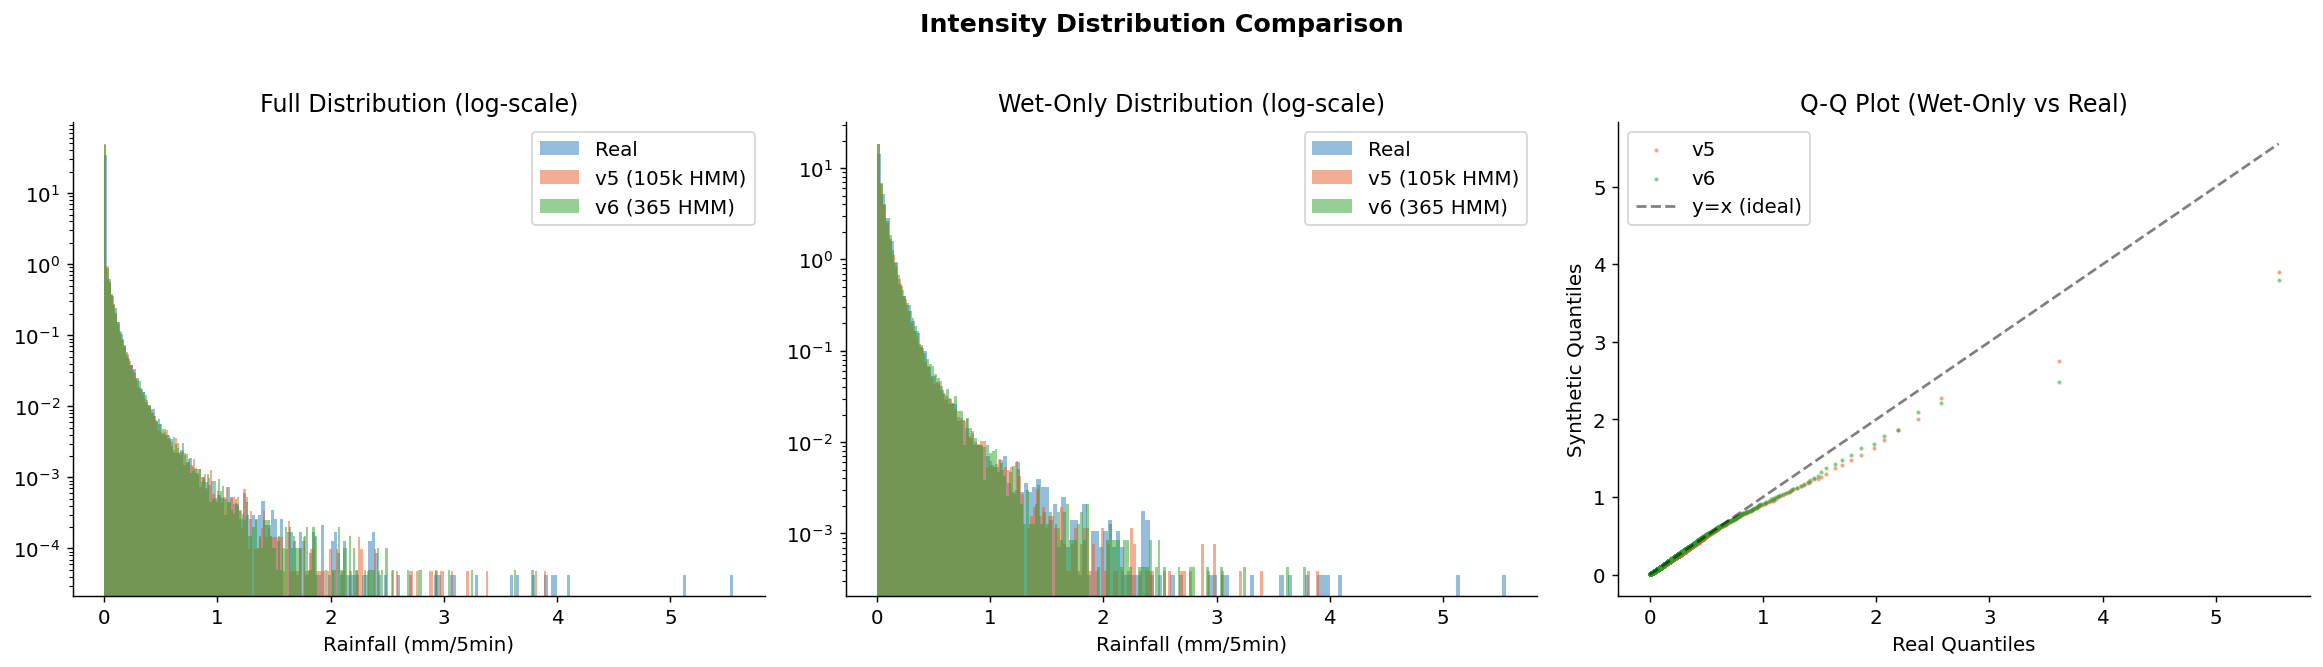


── KS Tests ─────────────────────────────────────────────
  Real vs v5 (wet)    : KS stat=0.08404, p=4.11e-266
  Real vs v6 (wet)    : KS stat=0.08648, p=1.77e-273

── Jensen-Shannon Divergence (wet-only) ─────────────────
  JSD(Real, v5): 0.02872
  JSD(Real, v6): 0.02609
  JSD(v5,   v6): 0.02361


In [4]:
real_nz = real[real > 0]
v5_nz   = v5[v5 > 0]
v6_nz   = v6[v6 > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Intensity Distribution Comparison', fontsize=14, fontweight='bold', y=1.02)

# Full distribution (log-scale)
ax = axes[0]
for arr, label in [(real, 'Real'), (v5, 'v5 (105k HMM)'), (v6, 'v6 (365 HMM)')]:
    ax.hist(arr, bins=200, density=True, alpha=0.5, label=label, color=COLORS[label])
ax.set_yscale('log'); ax.set_title('Full Distribution (log-scale)')
ax.set_xlabel('Rainfall (mm/5min)'); ax.legend()

# Wet-only distribution
ax = axes[1]
for arr, label in [(real_nz, 'Real'), (v5_nz, 'v5 (105k HMM)'), (v6_nz, 'v6 (365 HMM)')]:
    ax.hist(arr, bins=150, density=True, alpha=0.5, label=label, color=COLORS[label])
ax.set_yscale('log'); ax.set_title('Wet-Only Distribution (log-scale)')
ax.set_xlabel('Rainfall (mm/5min)'); ax.legend()

# QQ Plot (wet-only)
ax = axes[2]
n_qq = min(len(real_nz), len(v5_nz), len(v6_nz), 10000)
q_r  = np.quantile(np.sort(real_nz), np.linspace(0, 1, n_qq))
q_v5 = np.quantile(np.sort(v5_nz),   np.linspace(0, 1, n_qq))
q_v6 = np.quantile(np.sort(v6_nz),   np.linspace(0, 1, n_qq))
ax.scatter(q_r, q_v5, s=2, alpha=0.4, label='v5', color=COLORS['v5 (105k HMM)'])
ax.scatter(q_r, q_v6, s=2, alpha=0.4, label='v6', color=COLORS['v6 (365 HMM)'])
ax.plot([0, q_r.max()], [0, q_r.max()], 'k--', alpha=0.5, label='y=x (ideal)')
ax.set_title('Q-Q Plot (Wet-Only vs Real)'); ax.set_xlabel('Real Quantiles'); ax.set_ylabel('Synthetic Quantiles')
ax.legend()

plt.tight_layout(); plt.show()

# KS Tests
print('\n── KS Tests ─────────────────────────────────────────────')
for label, arr_nz in [('v5 (wet)', v5_nz), ('v6 (wet)', v6_nz)]:
    ks, p = stats.ks_2samp(real_nz, arr_nz)
    print(f'  Real vs {label:12s}: KS stat={ks:.5f}, p={p:.2e}')

# JSD
print('\n── Jensen-Shannon Divergence (wet-only) ─────────────────')
bins = np.linspace(0.001, max(real_nz.max(), v5_nz.max(), v6_nz.max()), 200)
hr, _ = np.histogram(real_nz, bins=bins, density=True)
h5, _ = np.histogram(v5_nz,   bins=bins, density=True)
h6, _ = np.histogram(v6_nz,   bins=bins, density=True)
hr, h5, h6 = hr+1e-12, h5+1e-12, h6+1e-12
print(f'  JSD(Real, v5): {jensenshannon(hr, h5):.5f}')
print(f'  JSD(Real, v6): {jensenshannon(hr, h6):.5f}')
print(f'  JSD(v5,   v6): {jensenshannon(h5, h6):.5f}')

## 4. Wet/Dry Spell Analysis

1 step = 5 minutes


,Real,v5 (105k HMM),v6 (365 HMM)
Metric,,,
Num wet spells,11604.00000,18501.00000,17250.00000
Mean wet (steps),6.57000,5.40000,5.41000
Median wet (steps),2.00000,2.00000,3.00000
Max wet (steps),277.00000,63.00000,59.00000
Num dry spells,11604.00000,18502.00000,17251.00000
Mean dry (steps),65.71000,51.41000,55.52000
Median dry (steps),5.00000,13.00000,15.00000
Max dry (steps),9619.00000,1003.00000,1050.00000


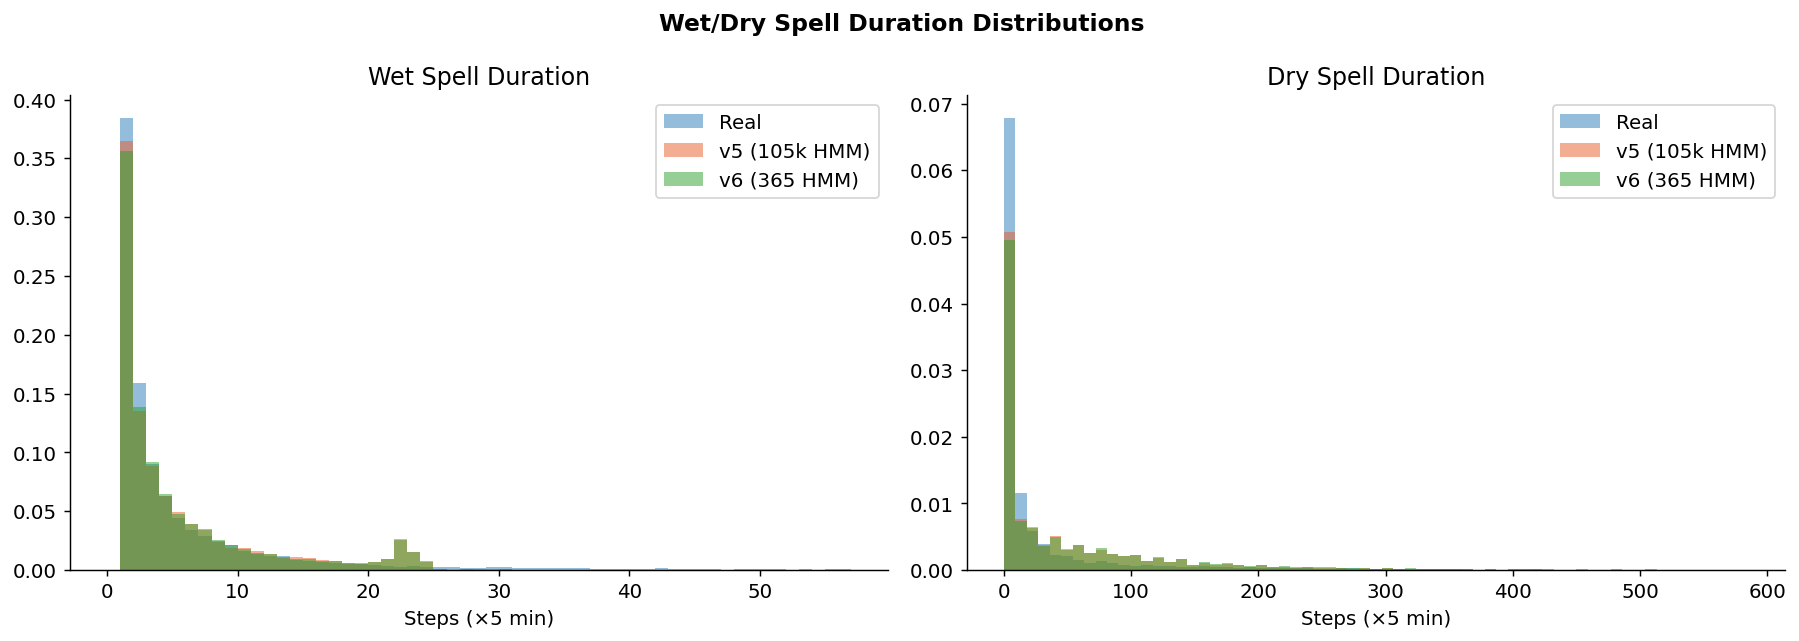


── KS Tests ─────────────────────────────────────────────
  v5: Wet KS=0.0467 (p=5.83e-14)   Dry KS=0.1726 (p=2.75e-186)
  v6: Wet KS=0.0467 (p=1.45e-13)   Dry KS=0.1848 (p=7.79e-208)


In [5]:
def extract_spells(arr):
    is_wet = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    return lengths[types == 1], lengths[types == 0]

wet_r, dry_r = extract_spells(real)
wet_5, dry_5 = extract_spells(v5)
wet_6, dry_6 = extract_spells(v6)

# Stats table
spell_df = pd.DataFrame({
    'Metric'           : ['Num wet spells', 'Mean wet (steps)', 'Median wet (steps)', 'Max wet (steps)',
                          'Num dry spells', 'Mean dry (steps)', 'Median dry (steps)', 'Max dry (steps)'],
    'Real'             : [len(wet_r), wet_r.mean(), np.median(wet_r), wet_r.max(),
                          len(dry_r), dry_r.mean(), np.median(dry_r), dry_r.max()],
    'v5 (105k HMM)'    : [len(wet_5), wet_5.mean(), np.median(wet_5), wet_5.max(),
                          len(dry_5), dry_5.mean(), np.median(dry_5), dry_5.max()],
    'v6 (365 HMM)'     : [len(wet_6), wet_6.mean(), np.median(wet_6), wet_6.max(),
                          len(dry_6), dry_6.mean(), np.median(dry_6), dry_6.max()],
}).set_index('Metric')
print('1 step = 5 minutes')
display(spell_df.round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wet/Dry Spell Duration Distributions', fontsize=13, fontweight='bold')

max_wet = int(np.percentile(np.concatenate([wet_r, wet_5, wet_6]), 99.5) * 1.2)
bins_w  = np.arange(0, max_wet + 1)
for arr, label in [(wet_r, 'Real'), (wet_5, 'v5 (105k HMM)'), (wet_6, 'v6 (365 HMM)')]:
    axes[0].hist(arr, bins=bins_w, density=True, alpha=0.5, label=label, color=COLORS[label])
axes[0].set_title('Wet Spell Duration'); axes[0].set_xlabel('Steps (×5 min)'); axes[0].legend()

max_dry = int(np.percentile(np.concatenate([dry_r, dry_5, dry_6]), 99) * 1.2)
bins_d  = np.arange(0, max_dry + 1, max(1, max_dry // 60))
for arr, label in [(dry_r, 'Real'), (dry_5, 'v5 (105k HMM)'), (dry_6, 'v6 (365 HMM)')]:
    axes[1].hist(arr, bins=bins_d, density=True, alpha=0.5, label=label, color=COLORS[label])
axes[1].set_title('Dry Spell Duration'); axes[1].set_xlabel('Steps (×5 min)'); axes[1].legend()

plt.tight_layout(); plt.show()

# KS Tests
print('\n── KS Tests ─────────────────────────────────────────────')
for label, w, d in [('v5', wet_5, dry_5), ('v6', wet_6, dry_6)]:
    ks_w, p_w = stats.ks_2samp(wet_r, w)
    ks_d, p_d = stats.ks_2samp(dry_r, d)
    print(f'  {label}: Wet KS={ks_w:.4f} (p={p_w:.2e})   Dry KS={ks_d:.4f} (p={p_d:.2e})')

## 5. Temporal Autocorrelation

Computing ACFs...
Done.


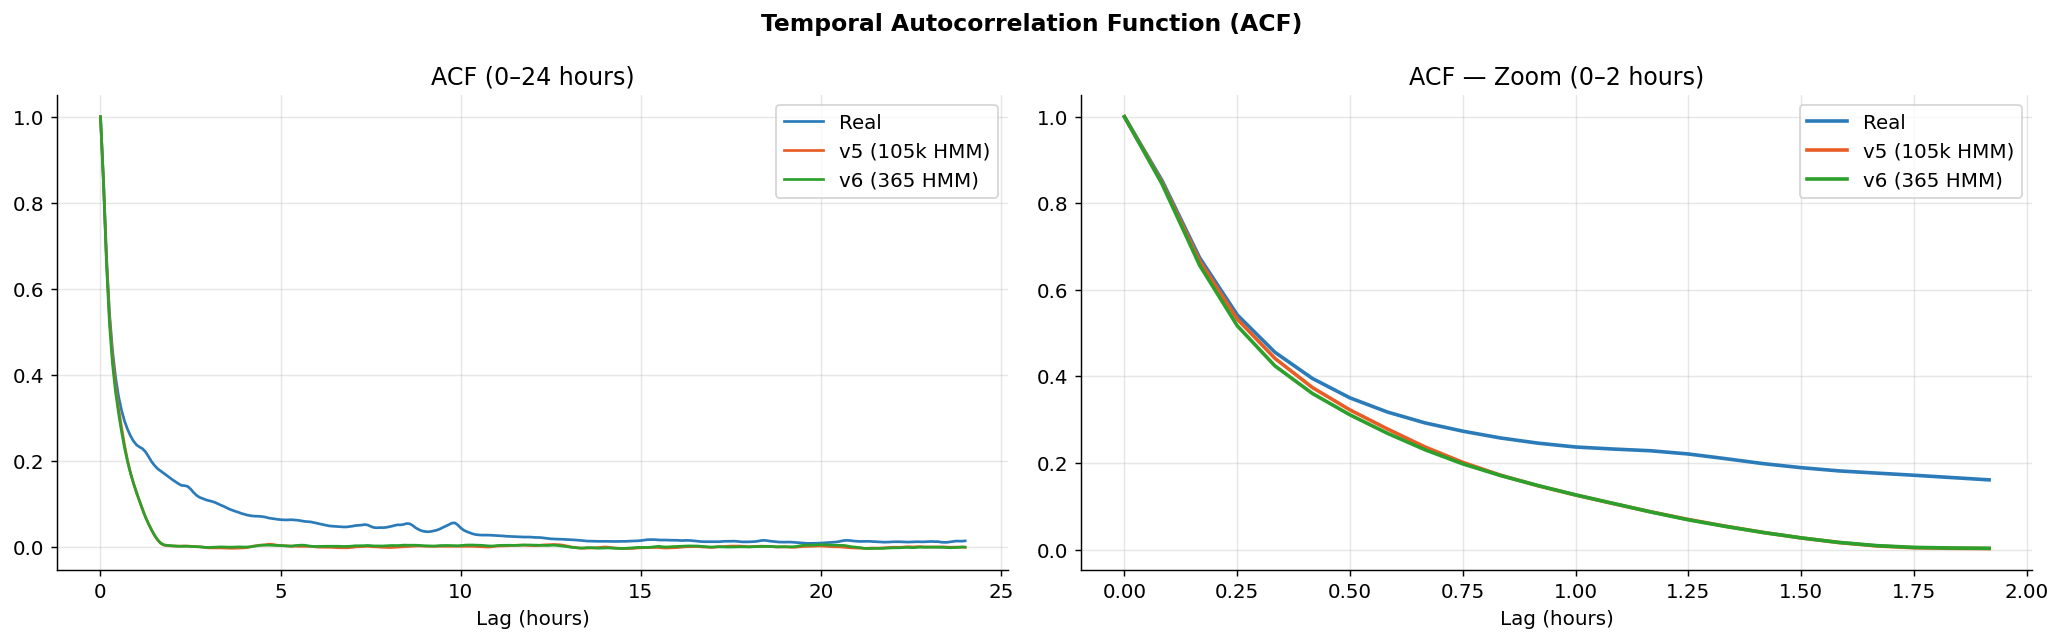


── ACF Error vs Real ─────────────────────────────────────
  v5: MAE=0.03933  RMSE=0.05529
  v6: MAE=0.03885  RMSE=0.05484


In [6]:
def compute_acf(arr, max_lag=288):  # 288 = 24 hours at 5-min
    n    = len(arr)
    mean = arr.mean()
    var  = arr.var()
    acf  = [np.mean((arr[:n-k] - mean) * (arr[k:] - mean)) / var if var > 0 else 0
            for k in range(max_lag + 1)]
    return np.array(acf)

MAX_LAG = 288  # 24 hours
print('Computing ACFs...')
acf_r = compute_acf(real, MAX_LAG)
acf_5 = compute_acf(v5,   MAX_LAG)
acf_6 = compute_acf(v6,   MAX_LAG)
print('Done.')

lags_hours = np.arange(MAX_LAG + 1) * 5 / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Temporal Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')

for acf, label in [(acf_r, 'Real'), (acf_5, 'v5 (105k HMM)'), (acf_6, 'v6 (365 HMM)')]:
    axes[0].plot(lags_hours, acf, label=label, color=COLORS[label], linewidth=1.5)
axes[0].set_title('ACF (0–24 hours)'); axes[0].set_xlabel('Lag (hours)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Zoom: first 2 hours
zoom = 24
for acf, label in [(acf_r, 'Real'), (acf_5, 'v5 (105k HMM)'), (acf_6, 'v6 (365 HMM)')]:
    axes[1].plot(lags_hours[:zoom], acf[:zoom], label=label, color=COLORS[label], linewidth=2)
axes[1].set_title('ACF — Zoom (0–2 hours)'); axes[1].set_xlabel('Lag (hours)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'\n── ACF Error vs Real ─────────────────────────────────────')
for label, acf in [('v5', acf_5), ('v6', acf_6)]:
    mae  = np.abs(acf_r - acf).mean()
    rmse = np.sqrt(((acf_r - acf)**2).mean())
    print(f'  {label}: MAE={mae:.5f}  RMSE={rmse:.5f}')

## 6. Extreme Value Analysis

,Real,v5 (105k),v6 (365),v5/Real,v6/Real
Percentile,,,,,
90.00000,0.00000,0.00000,0.00000,NaN,NaN
95.00000,0.03000,0.03026,0.02783,1.00871,0.92752
99.00000,0.16000,0.15897,0.16174,0.99359,1.01090
99.50000,0.25000,0.24311,0.25369,0.97243,1.01476
99.90000,0.56500,0.56737,0.56637,1.00419,1.00242


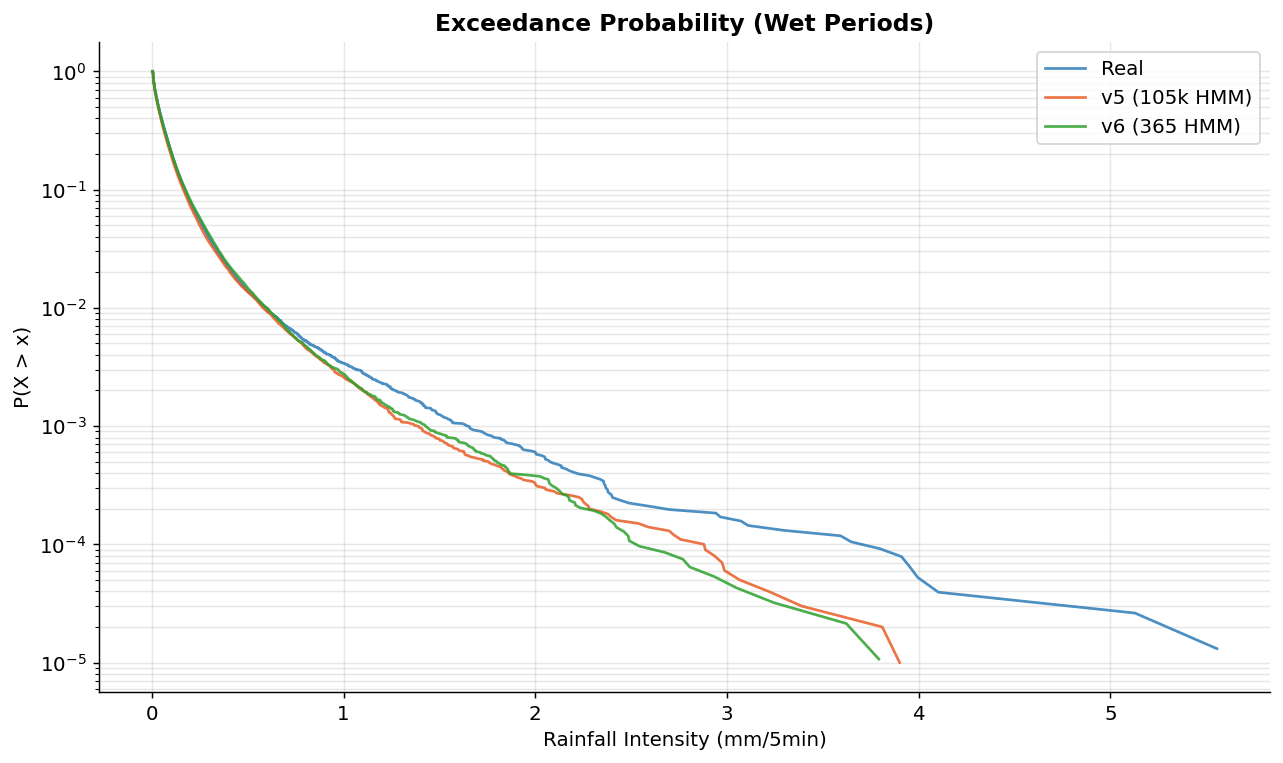

In [7]:
percentiles = [90, 95, 99, 99.5, 99.9]
extremes = pd.DataFrame({
    'Percentile'  : percentiles,
    'Real'        : [np.percentile(real, p) for p in percentiles],
    'v5 (105k)'   : [np.percentile(v5, p) for p in percentiles],
    'v6 (365)'    : [np.percentile(v6, p) for p in percentiles],
}).set_index('Percentile')
extremes['v5/Real'] = extremes['v5 (105k)'] / extremes['Real']
extremes['v6/Real'] = extremes['v6 (365)']  / extremes['Real']
display(extremes.round(5))

# Exceedance probability plot
fig, ax = plt.subplots(figsize=(10, 6))
for arr, label in [(real_nz, 'Real'), (v5_nz, 'v5 (105k HMM)'), (v6_nz, 'v6 (365 HMM)')]:
    s = np.sort(arr)[::-1]
    p = np.arange(1, len(s)+1) / len(s)
    ax.semilogy(s, p, label=label, color=COLORS[label], linewidth=1.5, alpha=0.85)
ax.set_title('Exceedance Probability (Wet Periods)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rainfall Intensity (mm/5min)'); ax.set_ylabel('P(X > x)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 7. Hourly & Daily Aggregation

,Hourly Mean,Hourly Std,Hourly Max,Daily Mean,Daily Std,Daily Max
Label,,,,,,
Real,0.08210,0.41800,18.20500,1.97080,4.13520,52.09750
v5 (105k HMM),0.08130,0.37810,13.70210,1.95150,2.39400,24.42040
v6 (365 HMM),0.08010,0.37990,15.11790,1.92160,2.41750,31.23610


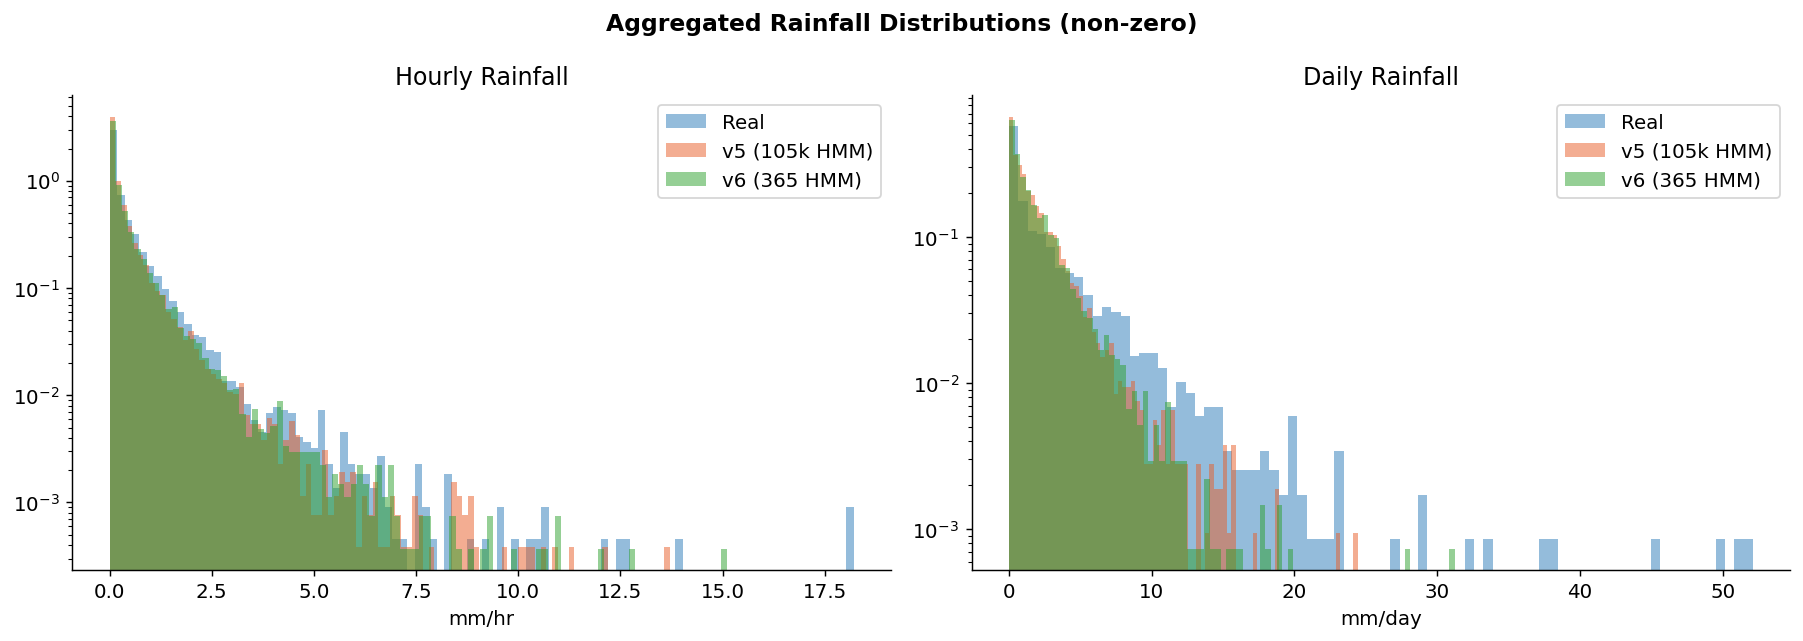

In [8]:
STEPS_PER_HOUR = 12   # 5-min resolution
STEPS_PER_DAY  = 288

def aggregate(arr, steps):
    n = len(arr) // steps
    return arr[:n * steps].reshape(-1, steps).sum(axis=1)

hourly = {l: aggregate(a, STEPS_PER_HOUR) for l, a in [('Real', real), ('v5 (105k HMM)', v5), ('v6 (365 HMM)', v6)]}
daily  = {l: aggregate(a, STEPS_PER_DAY)  for l, a in [('Real', real), ('v5 (105k HMM)', v5), ('v6 (365 HMM)', v6)]}

agg_df = pd.DataFrame({
    'Label'         : list(COLORS.keys()),
    'Hourly Mean'   : [hourly[l].mean() for l in COLORS],
    'Hourly Std'    : [hourly[l].std()  for l in COLORS],
    'Hourly Max'    : [hourly[l].max()  for l in COLORS],
    'Daily Mean'    : [daily[l].mean()  for l in COLORS],
    'Daily Std'     : [daily[l].std()   for l in COLORS],
    'Daily Max'     : [daily[l].max()   for l in COLORS],
}).set_index('Label')
display(agg_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Aggregated Rainfall Distributions (non-zero)', fontsize=13, fontweight='bold')
for arr, label in [(hourly[l][hourly[l]>0], l) for l in COLORS]:
    axes[0].hist(arr, bins=100, density=True, alpha=0.5, label=label, color=COLORS[label])
axes[0].set_yscale('log'); axes[0].set_title('Hourly Rainfall'); axes[0].set_xlabel('mm/hr'); axes[0].legend()

for arr, label in [(daily[l][daily[l]>0], l) for l in COLORS]:
    axes[1].hist(arr, bins=80, density=True, alpha=0.5, label=label, color=COLORS[label])
axes[1].set_yscale('log'); axes[1].set_title('Daily Rainfall'); axes[1].set_xlabel('mm/day'); axes[1].legend()

plt.tight_layout(); plt.show()

## 8. Storm Event Analysis

,N storms,Mean dur (steps),Mean peak (mm),Max peak (mm),Mean vol (mm),Mean peak pos
Label,,,,,,
Real,5387,12.65340,0.15360,5.55500,1.04720,0.36680
v5 (105k HMM),9243,9.53950,0.13740,3.90050,0.75500,0.39730
v6 (365 HMM),8706,9.46970,0.14680,3.79210,0.78990,0.39300


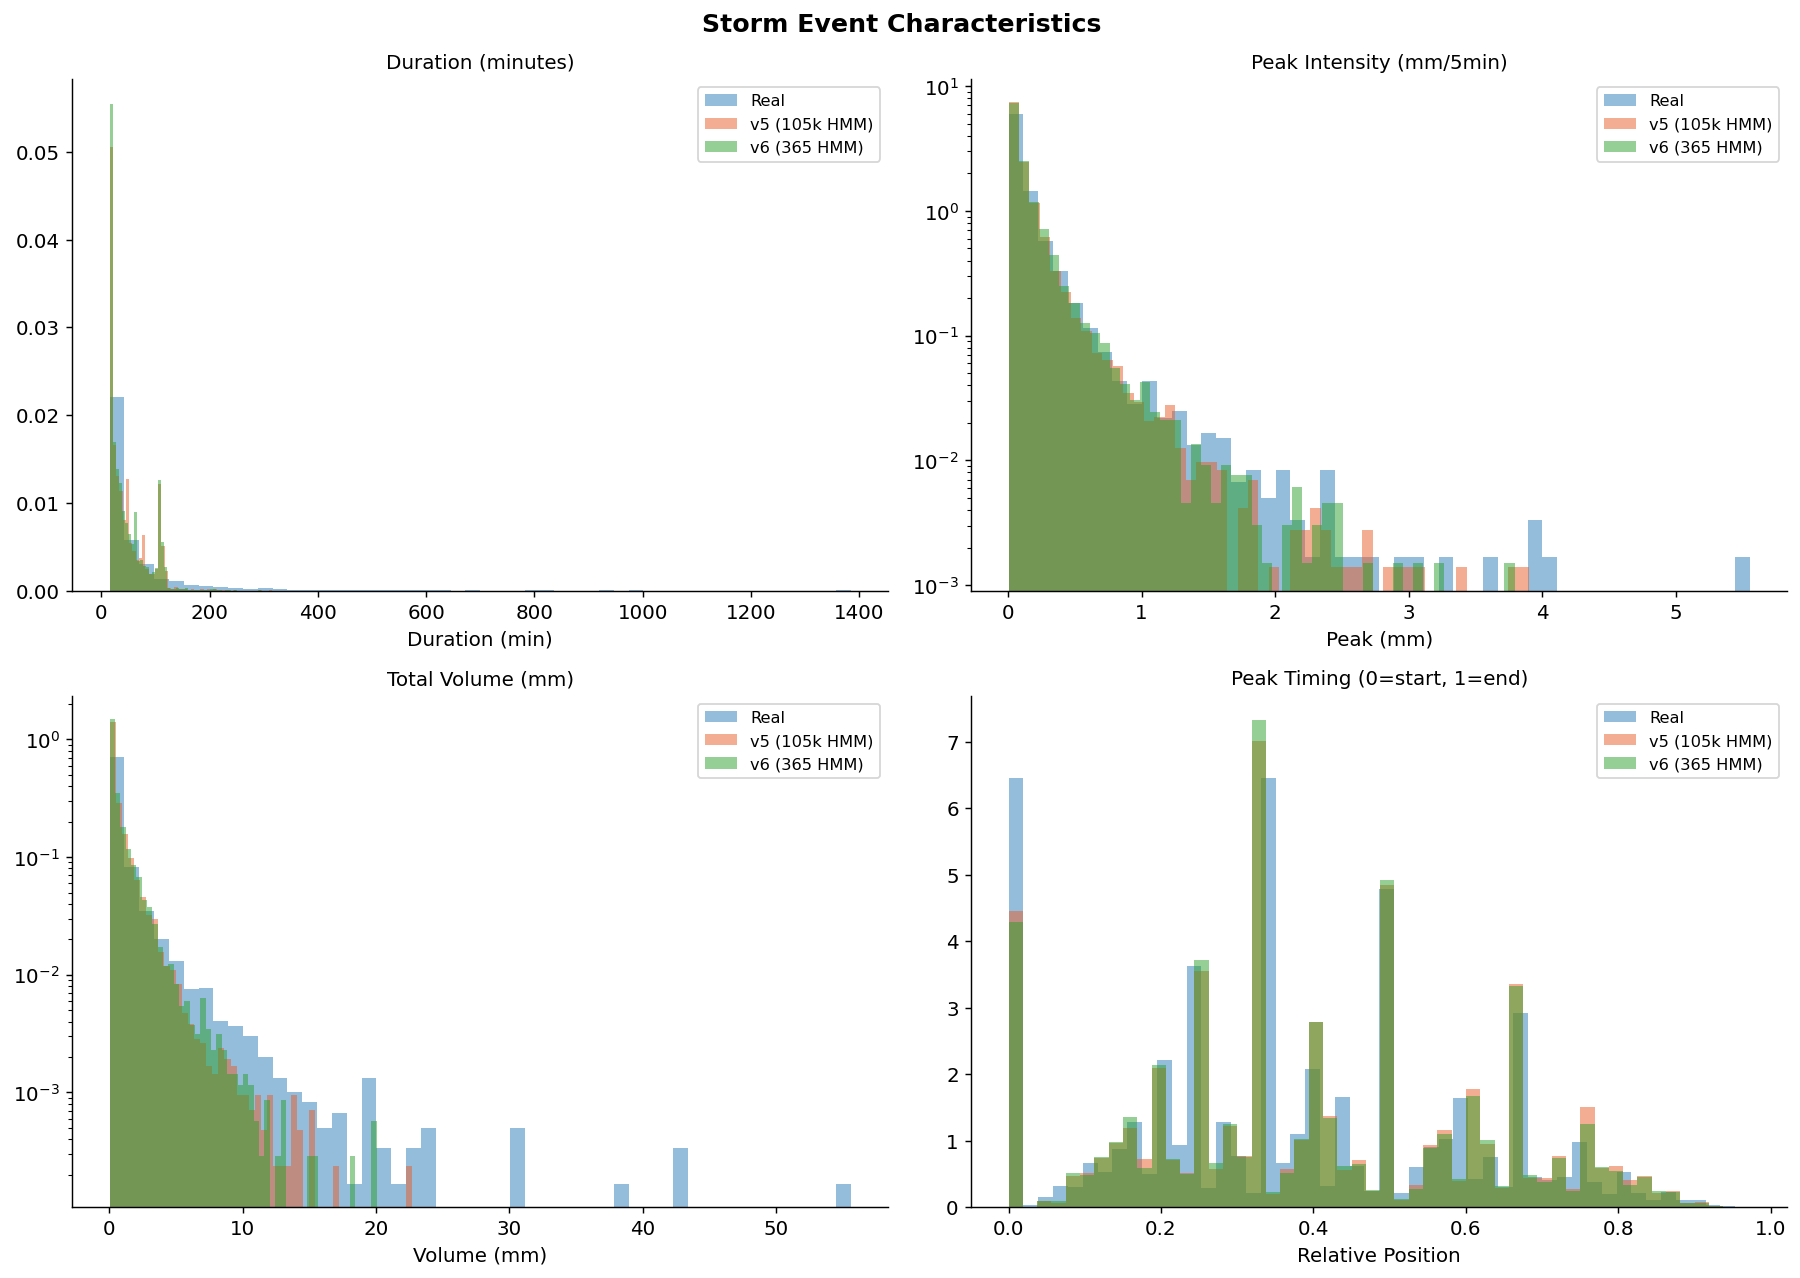

In [9]:
def extract_storms(arr, min_duration=3):
    is_wet  = (arr > 0).astype(int)
    changes = np.diff(is_wet, prepend=-1)
    starts  = np.where(changes != 0)[0]
    lengths = np.diff(np.append(starts, len(arr)))
    types   = is_wet[starts]
    storms = [arr[s:s+l] for s, l, t in zip(starts, lengths, types)
              if t == 1 and l >= min_duration]
    return storms

storms = {l: extract_storms(a) for l, a in [('Real', real), ('v5 (105k HMM)', v5), ('v6 (365 HMM)', v6)]}

storm_df = pd.DataFrame({
    'Label'           : list(COLORS.keys()),
    'N storms'        : [len(storms[l]) for l in COLORS],
    'Mean dur (steps)': [np.mean([len(s) for s in storms[l]]) for l in COLORS],
    'Mean peak (mm)'  : [np.mean([s.max() for s in storms[l]]) for l in COLORS],
    'Max peak (mm)'   : [np.max([s.max()  for s in storms[l]]) for l in COLORS],
    'Mean vol (mm)'   : [np.mean([s.sum() for s in storms[l]]) for l in COLORS],
    'Mean peak pos'   : [np.mean([np.argmax(s)/len(s) for s in storms[l]]) for l in COLORS],
}).set_index('Label')
display(storm_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Storm Event Characteristics', fontsize=14, fontweight='bold')

for name, idx, fn, xlabel in [
    ('Duration (minutes)', (0,0), lambda storms: np.array([len(s)*5 for s in storms]), 'Duration (min)'),
    ('Peak Intensity (mm/5min)', (0,1), lambda storms: np.array([s.max() for s in storms]), 'Peak (mm)'),
    ('Total Volume (mm)', (1,0), lambda storms: np.array([s.sum() for s in storms]), 'Volume (mm)'),
    ('Peak Timing (0=start, 1=end)', (1,1), lambda storms: np.array([np.argmax(s)/len(s) for s in storms]), 'Relative Position'),
]:
    ax = axes[idx]
    for label in COLORS:
        vals = fn(storms[label])
        ax.hist(vals, bins=50, density=True, alpha=0.5, label=label, color=COLORS[label])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel(xlabel)
    if 'Intensity' in name or 'Volume' in name:
        ax.set_yscale('log')
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

## 9. Sample Timeseries Visual

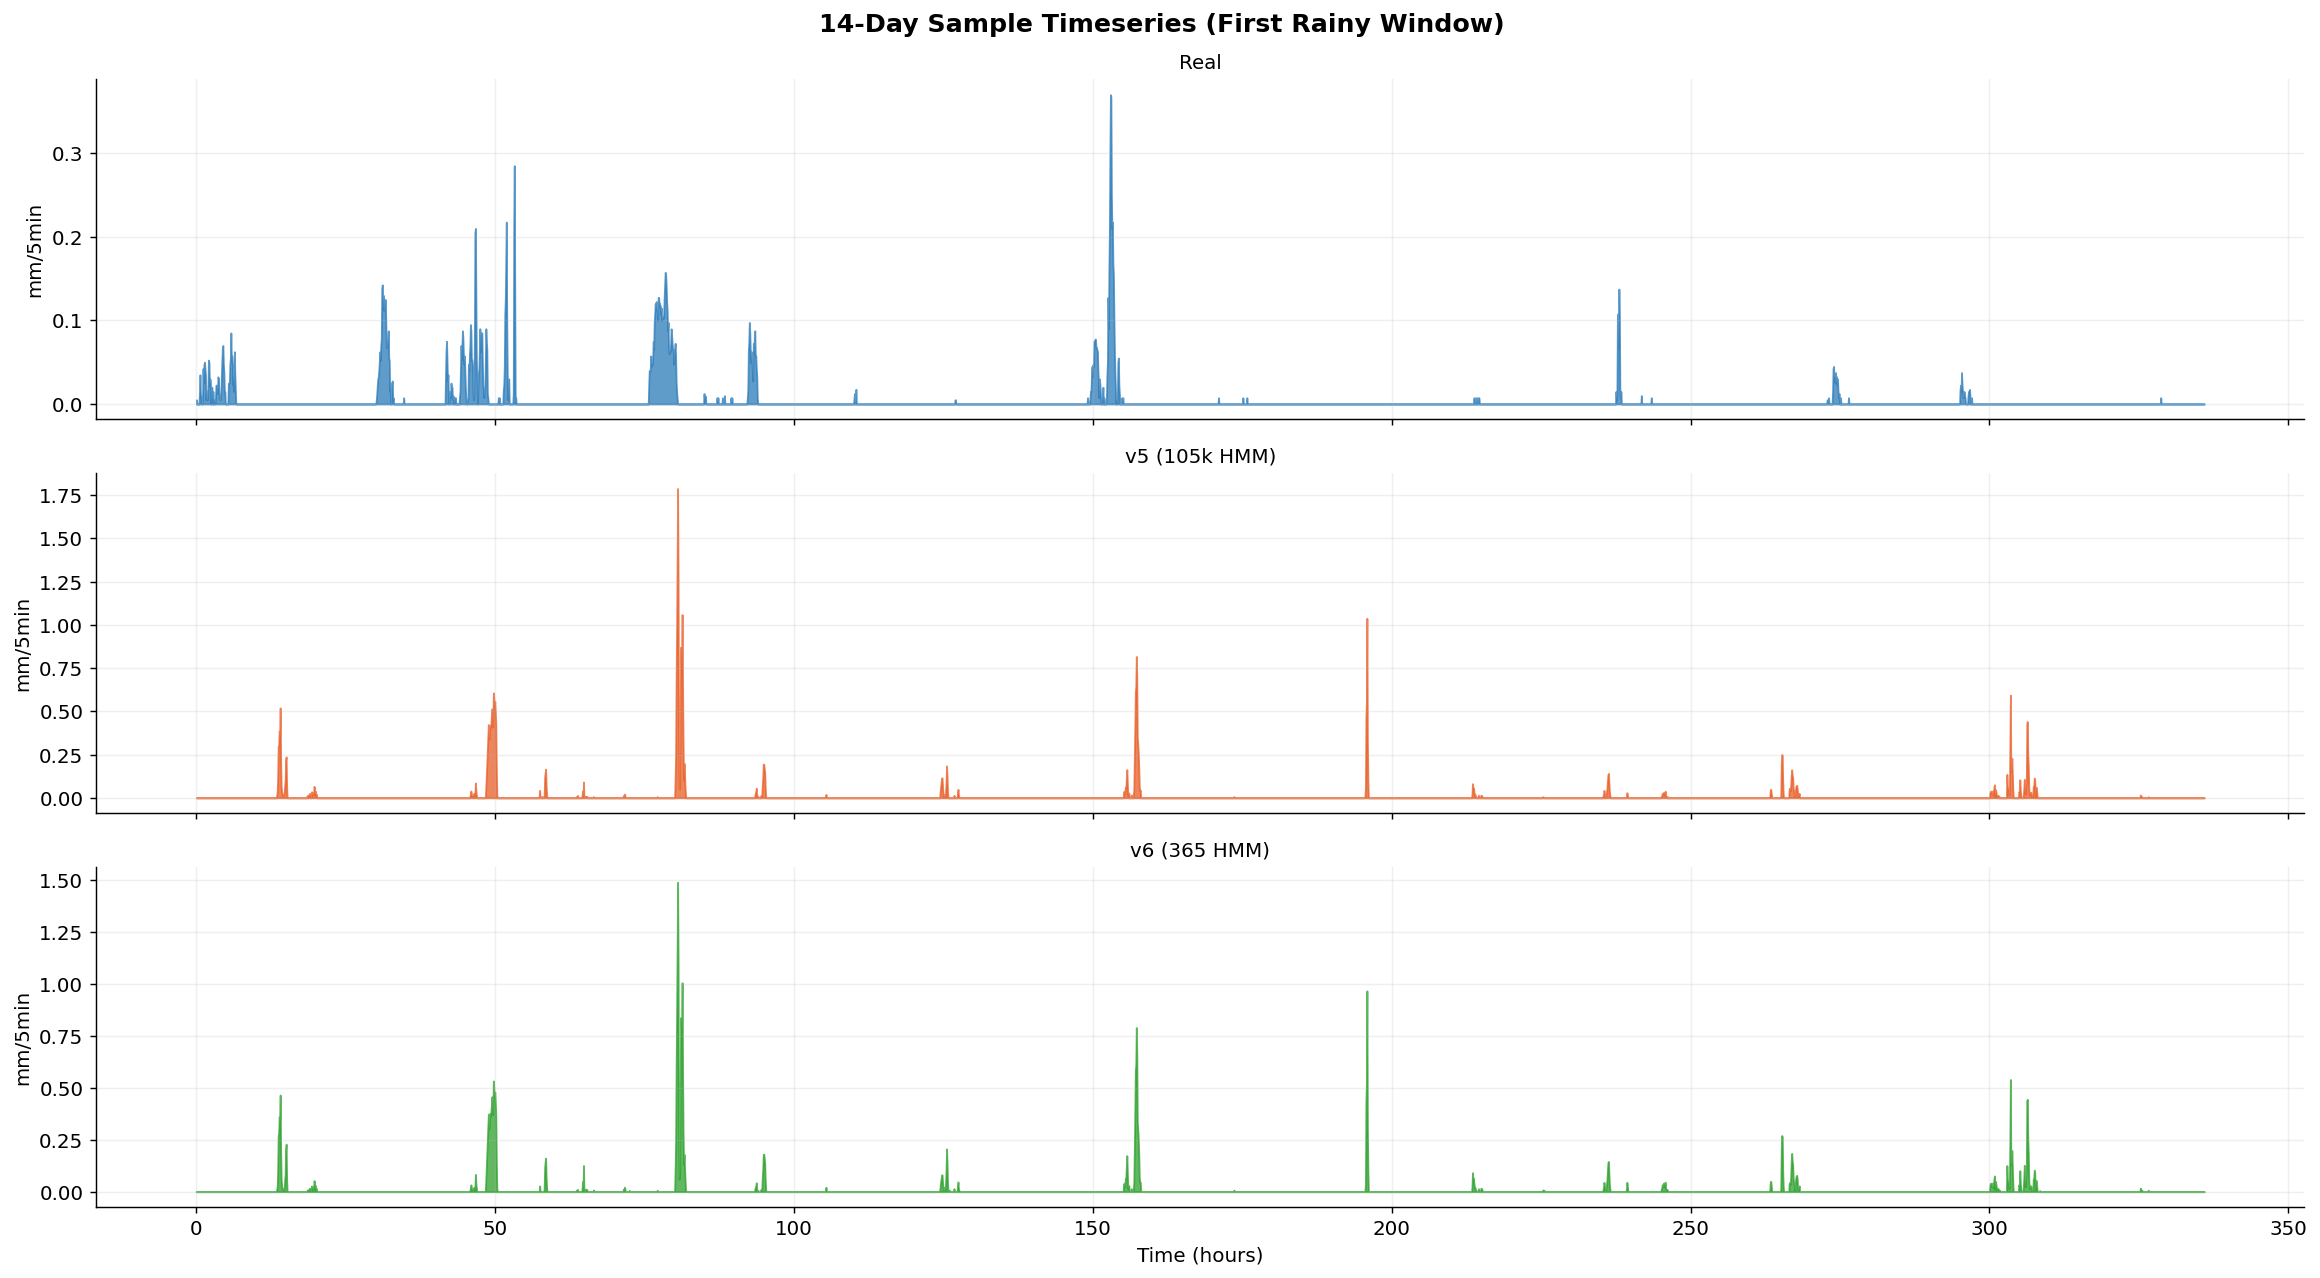

In [10]:
WINDOW = 288 * 14  # 14 days at 5-min

def find_rainy_window(arr, window, min_total=5):
    for start in range(0, len(arr) - window, 288):
        if arr[start:start+window].sum() > min_total:
            return arr[start:start+window]
    return arr[:window]

hours = np.arange(WINDOW) * 5 / 60

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
fig.suptitle('14-Day Sample Timeseries (First Rainy Window)', fontsize=14, fontweight='bold')

for ax, arr, label in zip(axes, [real, v5, v6], list(COLORS.keys())):
    w = find_rainy_window(arr, WINDOW)
    ax.fill_between(hours, w, alpha=0.75, color=COLORS[label])
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('mm/5min')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (hours)')
plt.tight_layout(); plt.show()

## 10. RL-Fitness Scorecard

  Dimension                               v5 (105k)    v6 (365)
  --------------------------------------------------------------
  Wet/Dry Ratio                         0.768 ███████████████░░░░░   0.888 █████████████████░░░
  Mean Intensity (wet)                  0.893 █████████████████░░░   0.995 ███████████████████░
  Distribution (JSD)                    0.885 █████████████████░░░   0.896 █████████████████░░░
  Autocorrelation                       0.607 ████████████░░░░░░░░   0.611 ████████████░░░░░░░░
  Storm Duration                        0.262 █████░░░░░░░░░░░░░░░   0.245 ████░░░░░░░░░░░░░░░░
  Extreme Values (P99)                  0.956 ███████████████████░   0.951 ███████████████████░
  Storm Count                           0.000 ░░░░░░░░░░░░░░░░░░░░   0.000 ░░░░░░░░░░░░░░░░░░░░
  Peak Timing                           0.847 ████████████████░░░░   0.869 █████████████████░░░

  OVERALL                                     0.652       0.682

  v5 (105k): ⚠️  CONDITIONAL (score=0

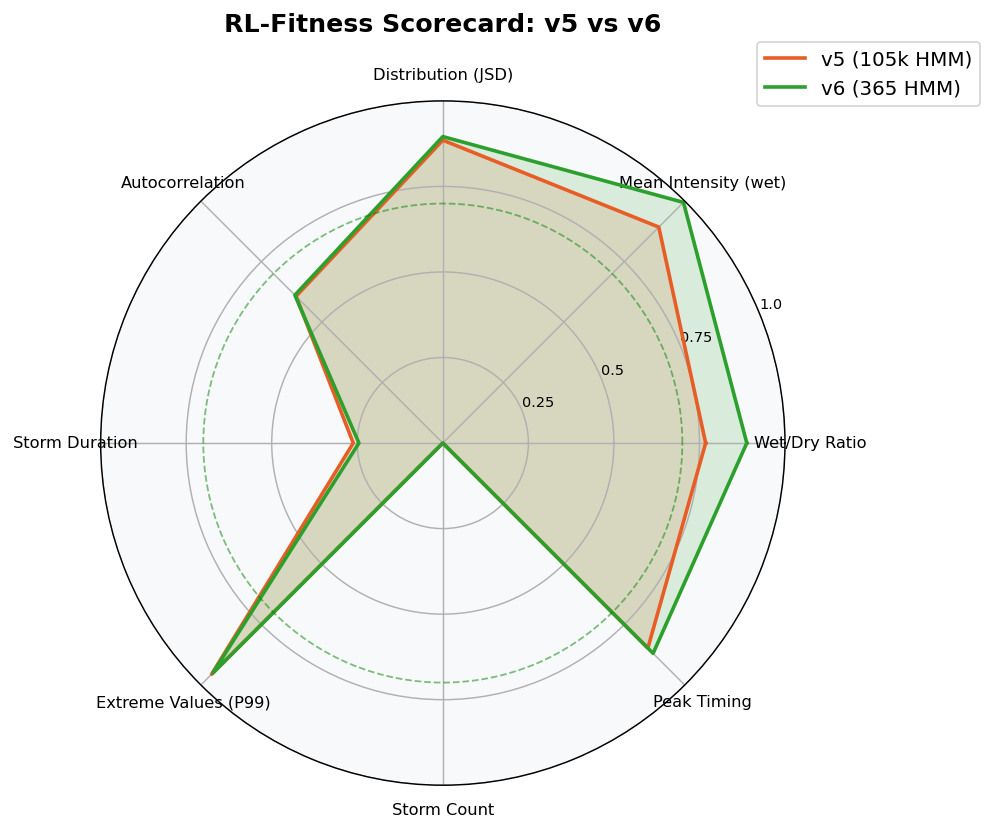

In [11]:
def compute_scores(synth_arr, synth_nz, wet_sp, dry_sp, storm_list, acf_synth, label):
    scores = {}

    # Wet/dry ratio
    err = abs((real > 0).mean() - (synth_arr > 0).mean()) / (real > 0).mean()
    scores['Wet/Dry Ratio']        = max(0, 1 - err * 5)

    # Mean intensity (wet)
    err = abs(real_nz.mean() - synth_nz.mean()) / real_nz.mean()
    scores['Mean Intensity (wet)'] = max(0, 1 - err * 2)

    # JSD (wet-only distribution)
    bins = np.linspace(0.001, max(real_nz.max(), synth_nz.max()), 200)
    hr, _ = np.histogram(real_nz, bins=bins, density=True); hr += 1e-12
    hs, _ = np.histogram(synth_nz, bins=bins, density=True); hs += 1e-12
    scores['Distribution (JSD)']   = max(0, 1 - jensenshannon(hr, hs) * 4)

    # ACF
    scores['Autocorrelation']      = max(0, 1 - np.abs(acf_r - acf_synth).mean() * 10)

    # Storm duration
    dur_r = np.array([len(s) for s in storms['Real']])
    dur_s = np.array([len(s) for s in storm_list])
    err = abs(dur_r.mean() - dur_s.mean()) / dur_r.mean()
    scores['Storm Duration']       = max(0, 1 - err * 3)

    # Extreme P99
    ratio = np.percentile(synth_nz, 99) / np.percentile(real_nz, 99)
    scores['Extreme Values (P99)'] = max(0, 1 - abs(1 - ratio) * 3)

    # Storm count
    ratio = len(storm_list) / len(storms['Real'])
    scores['Storm Count']          = max(0, 1 - abs(1 - ratio) * 2)

    # Peak timing
    pp_r = np.mean([np.argmax(s)/len(s) for s in storms['Real']])
    pp_s = np.mean([np.argmax(s)/len(s) for s in storm_list])
    scores['Peak Timing']          = max(0, 1 - abs(pp_r - pp_s) * 5)

    return scores

sc_v5 = compute_scores(v5, v5_nz, wet_5, dry_5, storms['v5 (105k HMM)'], acf_5, 'v5')
sc_v6 = compute_scores(v6, v6_nz, wet_6, dry_6, storms['v6 (365 HMM)'],  acf_6, 'v6')

# Print table
dims = list(sc_v5.keys())
print(f'  {"Dimension":35s}  {"v5 (105k)":>12s}  {"v6 (365)":>10s}')
print('  ' + '-'*62)
for d in dims:
    bar5 = '█' * int(sc_v5[d]*20) + '░'*(20-int(sc_v5[d]*20))
    bar6 = '█' * int(sc_v6[d]*20) + '░'*(20-int(sc_v6[d]*20))
    print(f'  {d:35s}  {sc_v5[d]:>6.3f} {bar5}  {sc_v6[d]:>6.3f} {bar6}')

ov5 = np.mean(list(sc_v5.values()))
ov6 = np.mean(list(sc_v6.values()))
print(f'\n  {"OVERALL":35s}  {ov5:>12.3f}  {ov6:>10.3f}')

for label, ov in [('v5 (105k)', ov5), ('v6 (365)', ov6)]:
    verdict = '✅ FIT' if ov >= 0.7 else ('⚠️  CONDITIONAL' if ov >= 0.5 else '❌ NOT FIT')
    print(f'\n  {label}: {verdict} (score={ov:.3f})')

# Radar chart
from matplotlib.patches import FancyArrowPatch
labels = dims
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')
for scores, label, color in [
    (sc_v5, 'v5 (105k HMM)', COLORS['v5 (105k HMM)']),
    (sc_v6, 'v6 (365 HMM)',  COLORS['v6 (365 HMM)']),
]:
    vals = [scores[d] for d in dims] + [scores[dims[0]]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=8)
ax.axhline(0.7, color='green', linewidth=1, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('RL-Fitness Scorecard: v5 vs v6', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

## 11. Head-to-Head: v5 vs v6 Summary

In [12]:
summary_rows = []
for label, arr, arr_nz, sc in [
    ('v5 (105k HMM)', v5, v5_nz, sc_v5),
    ('v6 (365 HMM)',  v6, v6_nz, sc_v6),
]:
    summary_rows.append({
        'Label'            : label,
        'Zero %'           : f"{(arr == 0).mean()*100:.2f}%",
        'Mean (wet mm)'    : f"{arr_nz.mean():.5f}",
        'Max (mm)'         : f"{arr.max():.4f}",
        'P99 (mm)'         : f"{np.percentile(arr_nz, 99):.5f}",
        'P99/Real'         : f"{np.percentile(arr_nz, 99)/np.percentile(real_nz, 99):.3f}x",
        'Overall RL Score' : f"{np.mean(list(sc.values())):.3f}",
        'Verdict'          : '✅ FIT' if np.mean(list(sc.values())) >= 0.7 else '⚠️  CHECK',
    })

pd.DataFrame(summary_rows).set_index('Label').T

Label,v5 (105k HMM),v6 (365 HMM)
Zero %,90.49%,91.12%
Mean (wet mm),0.07127,0.07511
Max (mm),3.9005,3.7921
P99 (mm),0.58128,0.59963
P99/Real,0.985x,1.016x
Overall RL Score,0.652,0.682
Verdict,⚠️ CHECK,⚠️ CHECK
